# SmartDs Quicklook Profiles

This notebook recreates the **line/scatter/histogram-style outputs** from the `batplotlib` `quicklook.py`, but using the current `starwinds-analysis` library and **without** Tecplot / VTK / PyVista.

Covered here:
- shell-integral line plots (mass loss, torque, open flux, axisymmetric flux fraction, energy flux)
- old-style scatter plots (`field vs radius`)
- Not covered here (placeholders included below):
- extracted Alfvén/current-sheet isosurfaces
- streamtraces / 3D streamline visualisation
- exact Tecplot 3D view state / annotations

## Setup

The sample file is a native 3D BATSRUS output from `sample_data/`.
We attach the BATSRUS + spherical recipe graphs through the library helper so derived SI quantities (`M_A`, `beta`, etc.) are available on demand.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from starwinds_analysis.data.samples import get_sample
from starwinds_analysis.smart_ds import SmartDs
from starwinds_analysis.quicklook2d import (
    compute_shell_diagnostics,
    plot_radius_quicklook,
    prepare_smartds_for_quicklook,
)

plt.rcParams["figure.dpi"] = 120
STAR_RADIUS_M = 6.957e8
STAR_MASS_KG = 1.98847e30


In [2]:
sample_path = get_sample("3d__var_1_n00060000.plt")
sds = SmartDs.from_file(sample_path)
prepare_smartds_for_quicklook(sds, body_radius_m=STAR_RADIUS_M)

sample_path

PosixPath('/Users/dagfev/Documents/starwinds/starwinds-analysis/sample_data/3d__var_1_n00060000.plt')

## Shell Radii (Quicklook-Style Integration Grid)

The old quicklook used a dense, non-uniform set of shell radii. Here we use a smaller set by default so the notebook runs quickly, but the plot shapes are the same kind of diagnostics.

In [3]:
x_native = np.unique(np.asarray(sds.variable("X [R]"), dtype=float))
native_radii = x_native[x_native >= 1.0]
print(f"Native unique X radii found: {native_radii.size}")
print(f"Native radius range: [{native_radii[0]:.6g}, {native_radii[-1]:.6g}] R")

# Keep the notebook responsive by selecting a small subset of native radii.
desired_heights = np.unique(np.concatenate([
    np.array([0.0, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]),
    np.geomspace(0.2, 20.0, 10),
]))
desired_radii = 1.0 + desired_heights
sel = np.searchsorted(native_radii, desired_radii, side="left")
sel = np.clip(sel, 0, native_radii.size - 1)
radii = np.unique(native_radii[sel])

# Keep this modest for a notebook. Increase to ~24x48 or more for smoother shell diagnostics.
N_POLAR = 12
N_AZIMUTH = 24

radii


Native unique X radii found: 28151
Native radius range: [1, 148] R


array([ 1.        ,  1.00100601,  1.00301194,  1.010028  ,  1.03018498,
        1.100052  ,  1.20001495,  1.33400702,  1.556692  ,  1.92875803,
        2.5485599 ,  3.58418703,  5.31026602,  8.1879158 , 12.99022961,
       21.00200081])

## Combined Shell Diagnostics (Quicklook2D Wrapper)

This single figure combines several quicklook outputs (`mass-loss`, `open-flux`, `axisymmetric-fraction`, `energy-loss`, and torque summaries).

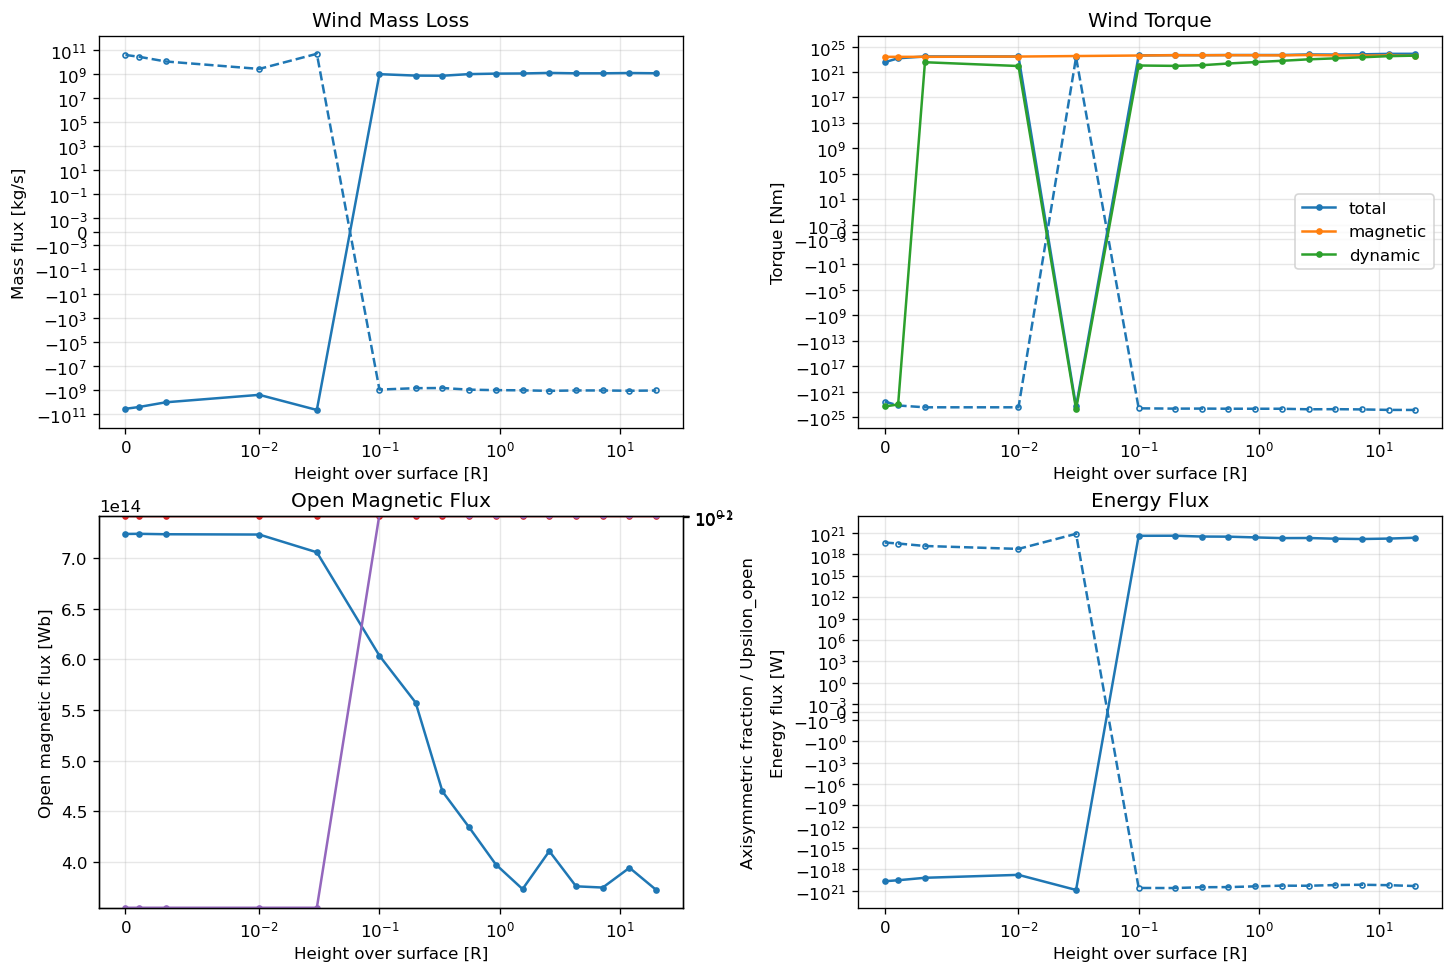

In [ ]:
# DONE this does not AT ALL adhere to the good/bad practices. PURGE the quicklook_shell_figure plotting aspect.
# This cell should only compute the shell diagnostics and return them.
diagnostics = compute_shell_diagnostics(
    sds,
    radii,
    body_radius_m=STAR_RADIUS_M,
    n_polar=N_POLAR,
    n_azimuth=N_AZIMUTH,
    method="nearest",
    include=("mass_loss", "torque", "open_flux", "energy", "axisymmetric_open_flux"),
)

diagnostics.keys()


## Quicklook-Style Split Line Plots (Same Diagnostics, Separate Panels)

This cell reconstructs the classic “one file per profile” style more directly, but still uses the new library-computed diagnostics.

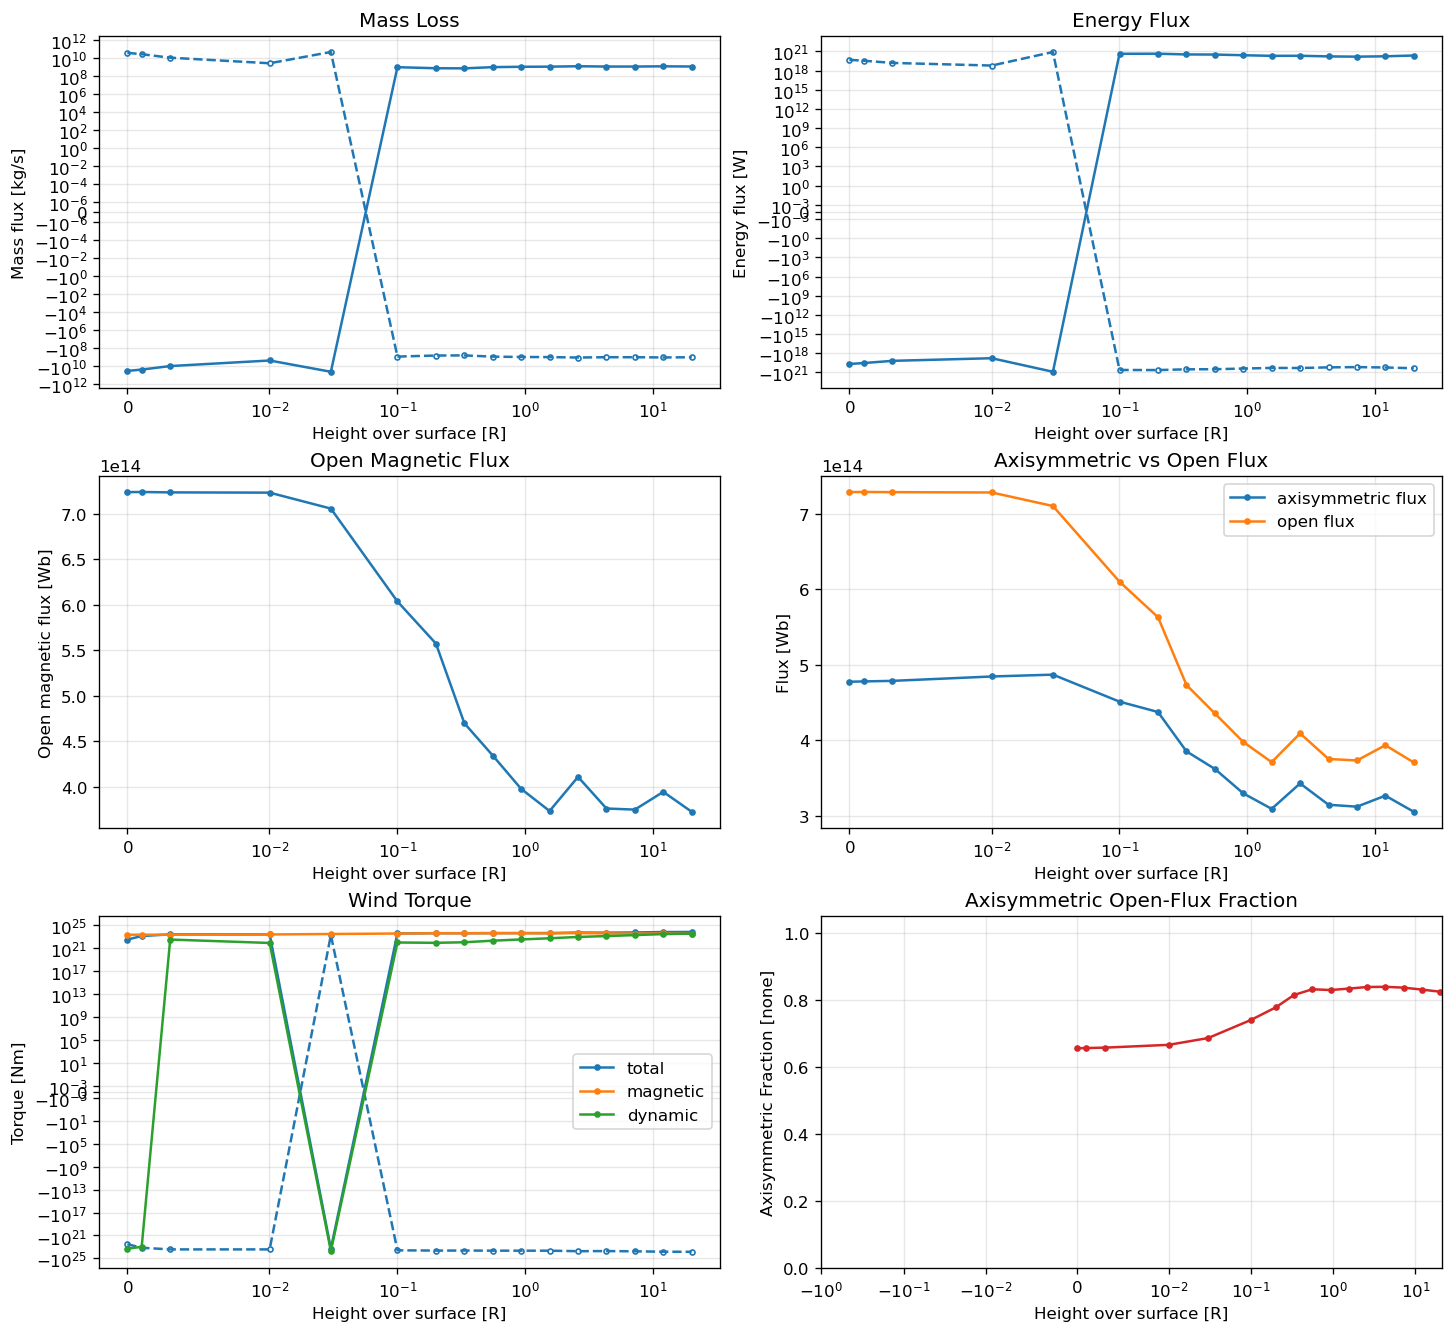

In [ ]:
# DONE you really do not follow instructions, do you. what are functions like plot_mass_loss_profile but a way to spit in my face?
fig, axs = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)
axs = np.asarray(axs)

mass = diagnostics["mass_loss"]
h = np.asarray(mass["height [R]"], dtype=float)
y = np.asarray(mass["mass_loss [kg/s]"], dtype=float)
axs[0, 0].plot(h, y, ".-", color="C0", label="mass loss")
axs[0, 0].plot(h, -y, ":", color="C0", alpha=0.6)
axs[0, 0].set_title("Mass Loss")
axs[0, 0].set_ylabel("Mass loss [kg/s]")
axs[0, 0].set_yscale("symlog", linthresh=1e-6)

energy = diagnostics["energy"]
h = np.asarray(energy["height [R]"], dtype=float)
y = np.asarray(energy["energy_flux [W]"], dtype=float)
axs[0, 1].plot(h, y, ".-", color="C0", label="energy flux")
axs[0, 1].plot(h, -y, ":", color="C0", alpha=0.6)
axs[0, 1].set_title("Energy Flux")
axs[0, 1].set_ylabel("Energy flux [W]")
axs[0, 1].set_yscale("symlog", linthresh=1e-3)

open_flux = diagnostics["open_flux"]
h = np.asarray(open_flux["height [R]"], dtype=float)
y = np.asarray(open_flux["open_flux [Wb]"], dtype=float)
axs[1, 0].plot(h, y, ".-", color="C0", label="open flux")
axs[1, 0].set_title("Open Magnetic Flux")
axs[1, 0].set_ylabel("Open magnetic flux [Wb]")

axif = diagnostics.get("axisymmetric_open_flux")
if axif is not None:
    h = np.asarray(axif["height [R]"], dtype=float)
    axs[1, 1].plot(h, np.asarray(axif["axisymmetric_open_flux [Wb]"], dtype=float), ".-", label="axisymmetric flux")
    axs[1, 1].plot(h, np.asarray(axif["open_flux [Wb]"], dtype=float), ".-", label="open flux")
    axs[1, 1].set_ylabel("Flux [Wb]")
    axs[1, 1].set_title("Axisymmetric vs Open Flux")
    axs[1, 1].legend(loc="best")
else:
    axs[1, 1].text(0.5, 0.5, "axisymmetric_open_flux not computed", ha="center", va="center")

torque = diagnostics["torque"]
h = np.asarray(torque["height [R]"], dtype=float)
tot = np.asarray(torque["total_torque [Nm]"], dtype=float)
mag = np.asarray(torque["magnetic_torque [Nm]"], dtype=float)
dyn = np.asarray(torque["dynamic_torque [Nm]"], dtype=float)
axs[2, 0].plot(h, tot, ".-", color="C0", label="total")
axs[2, 0].plot(h, -tot, ":", color="C0", alpha=0.6)
axs[2, 0].plot(h, mag, ".-", color="C1", label="magnetic")
axs[2, 0].plot(h, dyn, ".-", color="C2", label="dynamic")
axs[2, 0].set_title("Wind Torque")
axs[2, 0].set_ylabel("Torque [Nm]")
axs[2, 0].set_yscale("symlog", linthresh=1e-3)
axs[2, 0].legend(loc="best")

if axif is not None:
    h = np.asarray(axif["height [R]"], dtype=float)
    frac = np.asarray(axif["axisymmetric_open_flux_fraction [none]"], dtype=float)
    axs[2, 1].plot(h, frac, ".-", color="C3")
    axs[2, 1].set_ylabel("Axisymmetric Fraction [none]")
    axs[2, 1].set_ylim(0, 1.05)
    axs[2, 1].set_title("Axisymmetric Open-Flux Fraction")
else:
    axs[2, 1].text(0.5, 0.5, "axisymmetric_open_flux not computed", ha="center", va="center")

for ax in axs.ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)

for ax in axs[1:, :].ravel():
    ax.set_xlabel("Height over surface [R]")
plt.show()


## Scatter Plots (`field` vs `radius`)

These are direct point plots (no shell averaging).

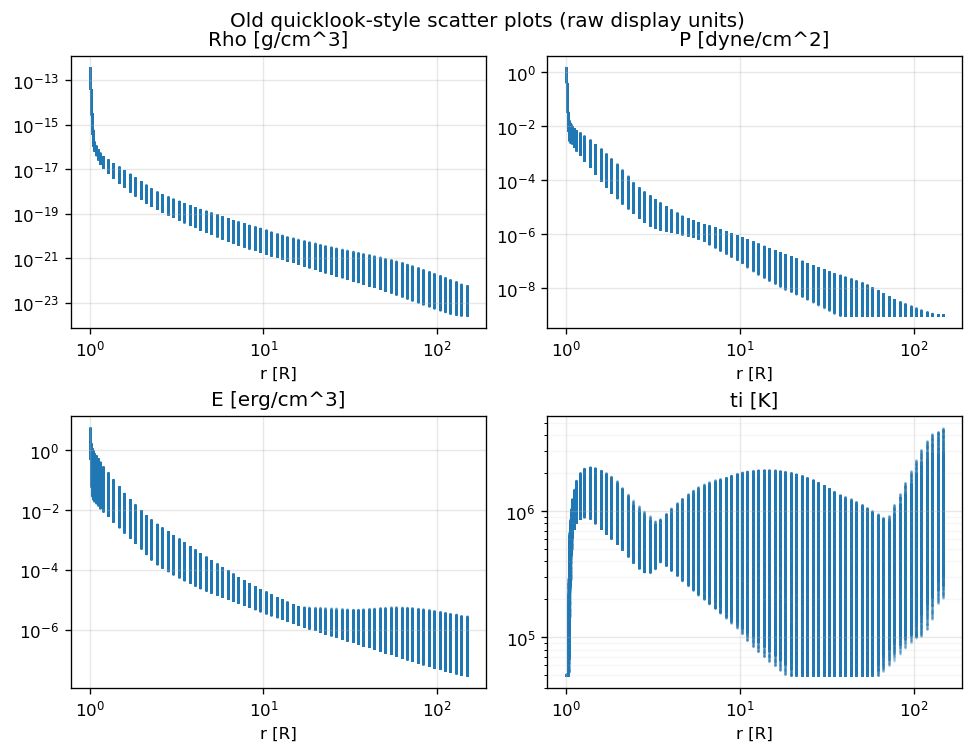

In [ ]:
# DONE just assume these fields are present.
raw_scatter_fields = (
    "Rho [g/cm^3]",
    "P [dyne/cm^2]",
    "E [erg/cm^3]",
    "ti [K]",
)

fig, axs = plot_radius_quicklook(sds, fields=raw_scatter_fields, mode="scatter", ncols=2, s=0.2, alpha=0.12)
for ax in np.asarray(axs).ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
fig.suptitle("Old quicklook-style scatter plots (raw display units)", y=1.02)
plt.show()


## Binned Radial Profiles (SI-First)

This is a cleaner replacement for some of the old radial trend inspection plots, using SI or derived fields where available.

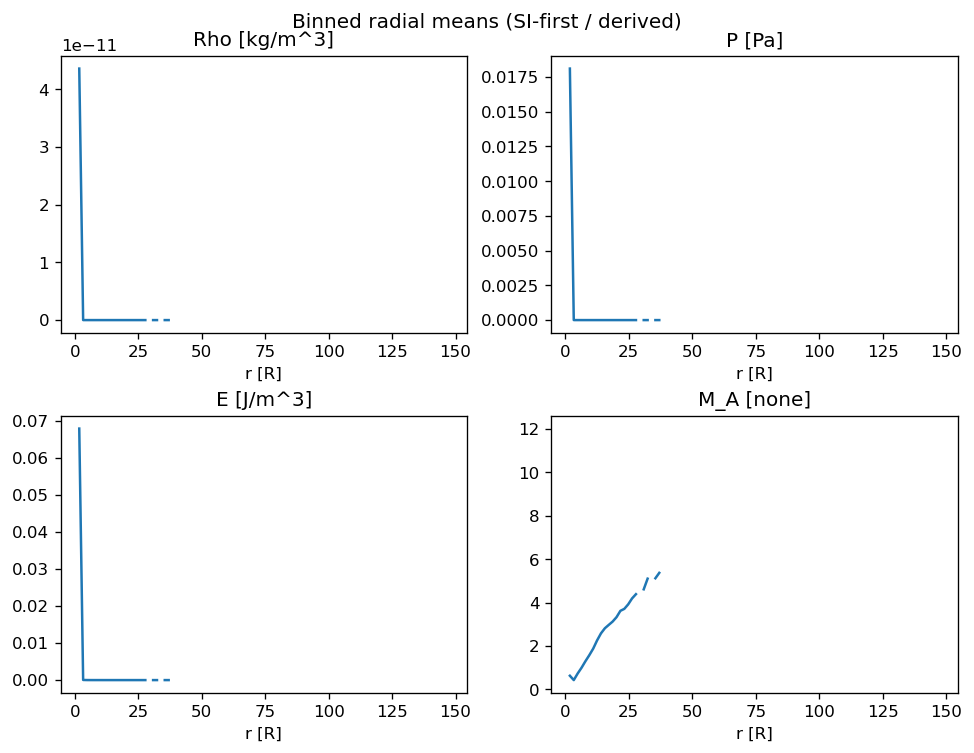

In [ ]:
# DONE Same as above look like shite. I am not even sure what the idfference is.
si_binned_fields = (
    "Rho [kg/m^3]",
    "P [Pa]",
    "E [J/m^3]",
    "M_A [none]",
)

fig, axs = plot_radius_quicklook(sds, fields=si_binned_fields, mode="binned", ncols=2, bins=96, statistic="mean")
for ax in np.asarray(axs).ravel():
    ax.set_xscale("symlog", linthresh=1e-2)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
fig.suptitle("Binned radial means (SI-first / derived)", y=1.02)
plt.show()


## Placeholders: Old Quicklook Features That Still Need VTK/Tecplot-Like Geometry

These are intentionally **not** implemented in this notebook yet:

1. **Extracted Alfvén isosurface torque** (old quicklook overlaid Alfvén-surface torque markers in the torque plot).
2. **Current-sheet / Alfvén surface isosurface extraction and 3D rendering**.
3. **Streamtrace generation and visualization** (the old quicklook did Tecplot streamtraces).

The line/shell diagnostics above are still fully useful without these, and already cover the high-priority wind mass-loss and torque profiles.

In [8]:
print("Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).")

Placeholder: Alfvén/current-sheet extracted surfaces and streamtraces are deferred (VTK/Tecplot geometry path).
